In [1]:

import pandas as pd
import numpy as np

df = pd.read_csv(
    "C:/Users/nanaa/OneDrive/Naive Bayes Nana Anderson/data set phishing websites.csv",
    sep=";",
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

df.columns = [str(c).strip().replace("ï»¿", "").replace("\ufeff", "") for c in df.columns]

print(df.shape)
print(df.columns.tolist())
print(df.head())

(235795, 78)
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed

In [2]:
# rommelkolommen weg
df = df.loc[:, ~df.columns.str.startswith("Unnamed", na=False)].copy()

# targetkolom zoeken
target_candidates = [col for col in df.columns if "label" in str(col).lower()]
print("Target candidates:", target_candidates)

# basisopschoning
df = df.dropna(subset=["FILENAME", "URL"]).copy()
df = df[df["FILENAME"].astype(str).str.endswith(".txt", na=False)]
df = df[df["URL"].astype(str).str.startswith(("http://", "https://"), na=False)]

print(df.shape)

Target candidates: ['label']
(235751, 56)


In [3]:
target_col = target_candidates[0]

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()

drop_cols = [target_col, "FILENAME", "URL", "Domain", "TLD", "Title"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.dropna(axis=1, how="all")
mask = ~X.isna().any(axis=1)

X = X.loc[mask].copy()
y = df.loc[mask, target_col].astype(int).copy()

print(X.shape)
print(y.shape)

(135622, 50)
(135622,)


the model strongly outperforms a dummy baseline, so the performance is not only caused by class imbalance. However, the near-perfect scores remain suspiciously high and may indicate that the dataset is extremely easy to separate or that some features are highly leakage-prone.”

In [5]:
print("Aantal missende waarden per kolom:")
print(df.isna().sum().sort_values(ascending=False).head(15))
print("Labelverdeling:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Aantal missende waarden per kolom:
FILENAME                0
URL                     0
URLLength               0
Domain                  0
DomainLength            0
IsDomainIP              0
TLD                     0
URLSimilarityIndex      0
CharContinuationRate    0
TLDLegitimateProb       0
URLCharProb             0
TLDLength               0
NoOfSubDomain           0
HasObfuscation          0
NoOfObfuscatedChar      0
dtype: int64
Labelverdeling:
label
1    132449
0      3173
Name: count, dtype: int64
label
1    0.976604
0    0.023396
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score
)

leakage_prone_cols = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "LineOfCode",
    "HasDescription",
    "HasCopyrightInfo",
    "Robots",
    "IsResponsive"
]

X_model = X.drop(columns=[c for c in leakage_prone_cols if c in X.columns], errors="ignore").copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Leakage-prone columns removed:", [c for c in leakage_prone_cols if c in X.columns])
print("Feature matrix used for modeling:", X_model.shape)
print("\nRandom Forest (leakage-reduced features)")
print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Leakage-prone columns removed: ['URLSimilarityIndex', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'LineOfCode', 'HasDescription', 'HasCopyrightInfo', 'Robots', 'IsResponsive']
Feature matrix used for modeling: (135622, 42)

Random Forest (leakage-reduced features)
Train accuracy: 1.0
Test accuracy: 0.9995944700460829
Balanced accuracy: 0.9913385826771653
ROC AUC: 0.9999966114088514

Confusion matrix:
[[  624    11]
 [    0 26490]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       635
           1       1.00      1.00      1.00     26490

    accuracy                           1.00     27125
   macro avg       1.00      0.99      1.00     27125
weighted avg       1.00      1.00      1.00     27125



In [54]:
#checking for vif scores.classification_report to check for multicollinearity between features.
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# numerieke features voor VIF
X_vif = X.copy()

# verwijder eventueel constante kolommen
nunique = X_vif.nunique()
X_vif = X_vif.loc[:, nunique > 1]

# voor de zekerheid rijen met missende waarden weg
X_vif = X_vif.dropna().copy()

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df = vif_df.sort_values("VIF", ascending=False)
print(vif_df.head(20))

                       Feature          VIF
0                    URLLength  8986.337414
12            NoOfLettersInURL  2855.791794
26          URLTitleMatchScore  2855.262533
25       DomainTitleMatchScore  2851.857413
10          NoOfObfuscatedChar  2688.734318
11            ObfuscationRatio  2084.860920
18          NoOfAmpersandInURL  1486.634281
14             NoOfDegitsInURL   894.977785
16             NoOfEqualsInURL   819.279042
19  NoOfOtherSpecialCharsInURL   686.936663
13            LetterRatioInURL   449.716966
1                 DomainLength   291.977776
24                    HasTitle   204.709824
20       SpacialCharRatioInURL   194.507505
4         CharContinuationRate   158.560567
3           URLSimilarityIndex   130.566040
21                     IsHTTPS   113.689607
6                  URLCharProb    87.337219
9               HasObfuscation    71.535658
7                    TLDLength    52.615824


VIF Analysis / Multicollinearity

The VIF analysis showed extremely high VIF scores for several predictors, indicating severe multicollinearity. This means that multiple engineered features contain overlapping information. This is especially important for Logistic Regression, where multicollinearity can lead to unstable coefficients and make the interpretation of individual predictors less reliable. For Random Forest, this is less critical because tree-based models are generally more robust to correlated predictors. However, multicollinearity can still distort feature importance estimates. Therefore, for the linear models, it is reasonable to remove some of the most strongly overlapping features.

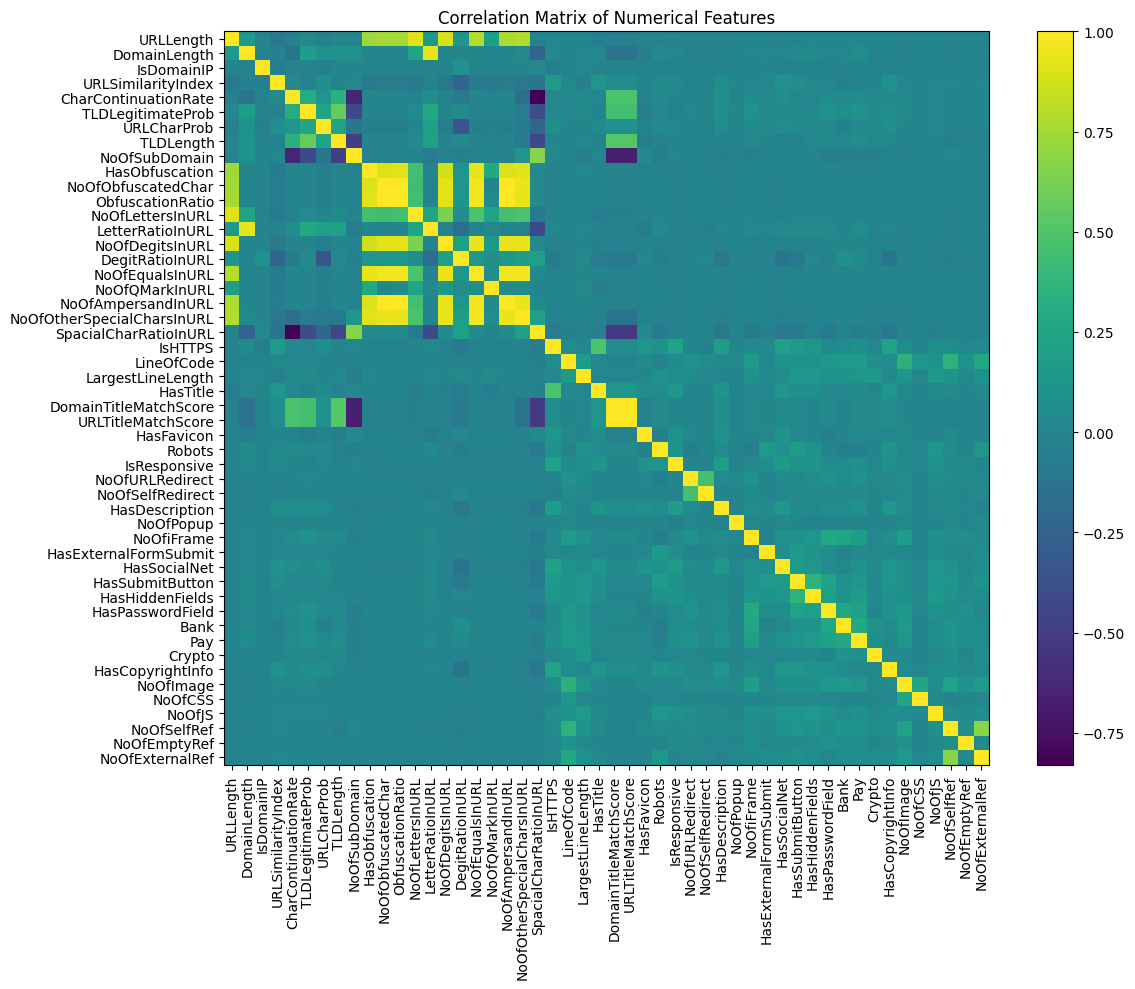

In [55]:

#checking for strong correlations between features
import matplotlib.pyplot as plt

corr_matrix = X.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix of Numerical Features")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.tight_layout()
plt.show()

In [56]:
#highest correlation features
corr_matrix = X.corr().abs()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if corr_value > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_value))

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)

for pair in high_corr_pairs[:20]:
    print(pair)

('DomainTitleMatchScore', 'URLTitleMatchScore', np.float64(0.9992782767555822))
('NoOfObfuscatedChar', 'NoOfAmpersandInURL', np.float64(0.9990126021888279))
('NoOfObfuscatedChar', 'ObfuscationRatio', np.float64(0.9982880268975112))
('ObfuscationRatio', 'NoOfAmpersandInURL', np.float64(0.9976566925000809))
('NoOfEqualsInURL', 'NoOfOtherSpecialCharsInURL', np.float64(0.9779531150435892))
('NoOfEqualsInURL', 'NoOfAmpersandInURL', np.float64(0.9695267949863103))
('NoOfObfuscatedChar', 'NoOfEqualsInURL', np.float64(0.9681355589437377))
('ObfuscationRatio', 'NoOfEqualsInURL', np.float64(0.9667486648243948))
('NoOfDegitsInURL', 'NoOfEqualsInURL', np.float64(0.9488469482678814))
('NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', np.float64(0.9432289555469828))
('NoOfObfuscatedChar', 'NoOfOtherSpecialCharsInURL', np.float64(0.9429840650325652))
('ObfuscationRatio', 'NoOfOtherSpecialCharsInURL', np.float64(0.9408346744044778))
('NoOfDegitsInURL', 'NoOfOtherSpecialCharsInURL', np.float64(0.9383

The correlation analysis shows that several predictors are very strongly correlated with each other, in some cases above 0.99. This indicates substantial multicollinearity and overlap between engineered features. For Random Forest this is generally less problematic, although it may affect feature importance interpretation. For Logistic Regression, however, this makes the coefficients less stable and the individual contribution of correlated predictors harder to interpret

In [6]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Dummy accuracy:", accuracy_score(y_test, dummy_pred))
print("Dummy balanced accuracy:", balanced_accuracy_score(y_test, dummy_pred))
print(classification_report(y_test, dummy_pred))

Dummy accuracy: 0.976589861751152
Dummy balanced accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       635
           1       0.98      1.00      0.99     26490

    accuracy                           0.98     27125
   macro avg       0.49      0.50      0.49     27125
weighted avg       0.95      0.98      0.97     27125



c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="balanced_accuracy")

print("CV balanced accuracy scores:", cv_scores)
print("Mean CV balanced accuracy:", cv_scores.mean())

CV balanced accuracy scores: [0.9992126  0.9976378  0.99605678 0.99921136 1.        ]
Mean CV balanced accuracy: 0.9984237065004098


The Random Forest does not merely exploit class imbalance or a lucky train-test split, because 5-fold cross-validation also yields near-perfect balanced accuracy.The Random Forest model strongly outperformed the dummy baseline, which confirms that the model is not simply benefiting from the imbalanced class distribution. In addition, 5-fold cross-validation yielded a mean balanced accuracy of approximately 0.998, which suggests that the result is stable across different data splits.
However, the near-perfect performance remains unusually high. Therefore, additional checks are required to determine whether the dataset is inherently easy to classify, contains duplicate observations, or includes highly predictive features that may act as leakage-like signals.

In [59]:
print("Duplicate rows in X:", X.duplicated().sum())
print("Duplicate rows in full df:", df.duplicated().sum())

Duplicate rows in X: 2
Duplicate rows in full df: 0


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

single_feature_scores = []

for col in X.columns:
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    score = cross_val_score(stump, X[[col]], y, cv=5, scoring="balanced_accuracy").mean()
    single_feature_scores.append((col, score))

single_feature_scores = sorted(single_feature_scores, key=lambda x: x[1], reverse=True)

for item in single_feature_scores[:10]:
    print(item)

('URLSimilarityIndex', np.float64(0.8725189398643781))
('LineOfCode', np.float64(0.8571680374710506))
('NoOfImage', np.float64(0.8484487069669662))
('NoOfExternalRef', np.float64(0.8252025488423218))
('NoOfJS', np.float64(0.820212209653775))
('IsHTTPS', np.float64(0.7973392284954917))
('LargestLineLength', np.float64(0.7376123313964301))
('NoOfOtherSpecialCharsInURL', np.float64(0.6559158818236619))
('SpacialCharRatioInURL', np.float64(0.6551979442866634))
('NoOfDegitsInURL', np.float64(0.6378060677273812))


The Random Forest model achieved near-perfect performance, which initially raised concerns about overfitting or data leakage.
However, several checks were performed. First, the model strongly outperformed a dummy baseline, indicating that the result was not merely caused by class imbalance. Second, 5-fold cross-validation also produced near-perfect balanced accuracy, suggesting that the result was stable across different train-test splits. Third, duplicate feature rows were almost absent and therefore cannot explain the performance. Finally, single-feature tests showed that no individual feature was able to achieve near-perfect classification on its own.
Therefore, the most plausible explanation is that the dataset is highly separable and that the Random Forest benefits from combining multiple highly informative predictors, rather than from classical overfitting or one obvious leakage feature.

In [61]:
rf_restricted = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_features=3,
    max_depth=5,
    min_samples_leaf=10
)



In [62]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score

# cross-validation
cv_scores_restricted = cross_val_score(
    rf_restricted, X, y, cv=5, scoring="balanced_accuracy"
)

print("Restricted RF CV balanced accuracy scores:", cv_scores_restricted)
print("Restricted RF Mean CV balanced accuracy:", cv_scores_restricted.mean())

# train/test evaluatie
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf_restricted.fit(X_train, y_train)
y_pred_restricted = rf_restricted.predict(X_test)
y_prob_restricted = rf_restricted.predict_proba(X_test)[:, 1]

print("\nRestricted RF train accuracy:", rf_restricted.score(X_train, y_train))
print("Restricted RF test accuracy:", accuracy_score(y_test, y_pred_restricted))
print("Restricted RF balanced accuracy:", balanced_accuracy_score(y_test, y_pred_restricted))
print("Restricted RF ROC AUC:", roc_auc_score(y_test, y_prob_restricted))

print("\nRestricted RF confusion matrix:")
print(confusion_matrix(y_test, y_pred_restricted))

print("\nRestricted RF classification report:")
print(classification_report(y_test, y_pred_restricted))

Restricted RF CV balanced accuracy scores: [0.99904272 0.99810432 0.99429074 0.99900373 0.99585536]
Restricted RF Mean CV balanced accuracy: 0.997259375712306

Restricted RF train accuracy: 0.9996221093670793
Restricted RF test accuracy: 0.9995944700460829
Restricted RF balanced accuracy: 0.9974867948980897
Restricted RF ROC AUC: 0.999980679085556

Restricted RF confusion matrix:
[[  632     3]
 [    8 26482]]

Restricted RF classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       635
           1       1.00      1.00      1.00     26490

    accuracy                           1.00     27125
   macro avg       0.99      1.00      1.00     27125
weighted avg       1.00      1.00      1.00     27125



The initial near-perfect Random Forest performance appeared suspicious and raised concerns about overfitting or leakage. However, several checks were performed.
First, the model strongly outperformed a dummy baseline, which showed that the result was not simply caused by class imbalance.
Second, 5-fold cross-validation also produced near-perfect balanced accuracy, meaning the result was stable across multiple data splits.
Third, duplicate observations were found to be negligible.
Fourth, no single feature was able to achieve near-perfect classification on its own.
Finally, a more restricted Random Forest with limited depth and fewer features per split still achieved almost the same performance.
Therefore, classical overfitting is not the most likely explanation. The most plausible explanation is that the dataset is highly separable and that the combination of multiple strong predictors makes the classification task unusually easy. I am now checking the performnace of a random forest without the best performing features.


In [63]:
cols_without_top = [c for c in X.columns if c not in [
    "URLSimilarityIndex", "LineOfCode", "NoOfImage"
]]

X_reduced = X[cols_without_top]

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
scores = cross_val_score(rf, X_reduced, y, cv=5, scoring="balanced_accuracy")
print(scores)
print(scores.mean())

[0.99448819 0.99685039 0.98578554 0.99526814 0.99133858]
0.992746169102438


The near-perfect performance is not driven by one single feature or a very small set of dominant predictors. Even after removing the strongest individual features, the model still performs extremely well. This suggests that the dataset contains multiple informative predictors and is highly separable, however i want to investigate if data leakage is an issue.

In [9]:
suspect_cols = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "LineOfCode",
    "HasDescription",
    "HasCopyrightInfo",
    "Robots",
    "IsResponsive",
    "Title"
]

X_safe = X.drop(columns=[c for c in suspect_cols if c in X.columns], errors="ignore")

print(X.shape, X_safe.shape)

(135622, 50) (135622, 42)


In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
scores_safe = cross_val_score(rf, X_safe, y, cv=5, scoring="balanced_accuracy")

print(scores_safe)
print(scores_safe.mean())

[0.99212598 0.99606299 0.98895899 0.99684543 0.99368191]
0.9935350608847127


In [11]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report

groups = df.loc[X_safe.index, "Domain"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_safe, y, groups=groups))

X_train_g, X_test_g = X_safe.iloc[train_idx], X_safe.iloc[test_idx]
y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train_g, y_train_g)
y_pred_g = rf.predict(X_test_g)

print("Group split balanced accuracy:", balanced_accuracy_score(y_test_g, y_pred_g))
print(classification_report(y_test_g, y_pred_g))

Group split balanced accuracy: 0.9935794542536116
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       623
           1       1.00      1.00      1.00     26502

    accuracy                           1.00     27125
   macro avg       1.00      0.99      1.00     27125
weighted avg       1.00      1.00      1.00     27125



In [67]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report

groups = df.loc[X_safe.index, "TLD"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(X_safe, y, groups=groups))

X_train_g, X_test_g = X_safe.iloc[train_idx], X_safe.iloc[test_idx]
y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(random_state=50, n_jobs=-3, class_weight="balanced")
rf.fit(X_train_g, y_train_g)
y_pred_g = rf.predict(X_test_g)

print("TLD group split balanced accuracy:", balanced_accuracy_score(y_test_g, y_pred_g))
print(classification_report(y_test_g, y_pred_g))

TLD group split balanced accuracy: 0.9867256637168141
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       113
           1       1.00      1.00      1.00      1433

    accuracy                           1.00      1546
   macro avg       1.00      0.99      0.99      1546
weighted avg       1.00      1.00      1.00      1546



In [68]:
def root_domain(domain):
    parts = str(domain).split(".")
    if len(parts) >= 2:
        return ".".join(parts[-2:])
    return str(domain)

groups = df.loc[X_safe.index, "Domain"].astype(str).apply(root_domain)

In [69]:
groups = df.loc[X_safe.index, "TLD"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
train_idx, test_idx = next(gss.split(X_safe, y, groups=groups))

X_train_g, X_test_g = X_safe.iloc[train_idx], X_safe.iloc[test_idx]
y_train_g, y_test_g = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(random_state=50, n_jobs=-3, class_weight="balanced")
rf.fit(X_train_g, y_train_g)
y_pred_g = rf.predict(X_test_g)

print("TLD group split balanced accuracy:", balanced_accuracy_score(y_test_g, y_pred_g))
print(classification_report(y_test_g, y_pred_g))

TLD group split balanced accuracy: 0.9867256637168141
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       113
           1       1.00      1.00      1.00      1433

    accuracy                           1.00      1546
   macro avg       1.00      0.99      0.99      1546
weighted avg       1.00      1.00      1.00      1546



Additional grouped evaluations based on both domain and TLD were performed. The model performance remained very high in both cases, although the TLD-based split resulted in a small decrease. This suggests that the high performance is robust across different splitting strategies and is therefore more likely explained by the strong separability of the dataset than by simple train-test overlap.

Now I am going to use the cleaned data set to make a Gaussian Naive bayes and logistic regression analyses. I am going to use one single split and i am going to standardise it so that it will be possible to analyse with the models mentioned. Also I am going to drop features that cause multicollinearity. The selected features were removed mainly to reduce multicollinearity and feature redundancy. The VIF analysis and correlation analysis showed that several predictors were extremely highly correlated with each other, meaning that they contained largely overlapping information. This is especially problematic for Logistic Regression, because strong multicollinearity can make the model coefficients unstable and reduce the interpretability of individual predictors.

The dropped features were chosen for three main reasons:

They were highly correlated with other predictors
Some features measured almost the same underlying pattern. For example, URLTitleMatchScore strongly overlapped with DomainTitleMatchScore, while NoOfLettersInURL strongly overlapped with URLLength.
They belonged to the same engineered feature family
Several features described very similar aspects of URL structure, obfuscation, or special-character usage. For example, NoOfObfuscatedChar, NoOfAmpersandInURL, NoOfEqualsInURL, NoOfOtherSpecialCharsInURL, LetterRatioInURL, and SpacialCharRatioInURL all captured closely related information about URL composition and obfuscation patterns. Keeping all of them would introduce unnecessary redundancy.
They added limited unique information compared with retained features
In each group of strongly overlapping variables, one or two representative features were kept, while the others were removed. This makes the feature set more compact without substantially reducing predictive information.

Overall, the purpose of dropping these features was not to artificially lower model performance, but to create a cleaner and more stable input set for Logistic Regression. This helps reduce redundancy, improve interpretability, and make the linear model more statistically reliable.


In [15]:
drop_lr_final = [
    "NoOfLettersInURL",
    "URLTitleMatchScore",
    "NoOfObfuscatedChar",
    "NoOfAmpersandInURL",
    "NoOfEqualsInURL",
    "NoOfOtherSpecialCharsInURL",
    "LetterRatioInURL",
    "SpacialCharRatioInURL",
    "TLDLength",
    "HasTitle",
    "CharContinuationRate",
    "NoOfDegitsInURL",
    "NoOfDigitsInURL",
    "NoOfSubDomain",
    "URLCharProb",
    "HasObfuscation"
]

In [16]:
X_lr_final = X_safe.drop(columns=[c for c in drop_lr_final if c in X_safe.columns], errors="ignore").copy()

print("Leakage-reduced shape:", X_safe.shape)
print("Final shape for Logistic Regression / Naive Bayes:", X_lr_final.shape)
print("Dropped columns:", [c for c in drop_lr_final if c in X_safe.columns])

Leakage-reduced shape: (135622, 42)
Final shape for Logistic Regression / Naive Bayes: (135622, 28)
Dropped columns: ['NoOfLettersInURL', 'NoOfObfuscatedChar', 'NoOfAmpersandInURL', 'NoOfEqualsInURL', 'NoOfOtherSpecialCharsInURL', 'LetterRatioInURL', 'SpacialCharRatioInURL', 'TLDLength', 'HasTitle', 'CharContinuationRate', 'NoOfDegitsInURL', 'NoOfSubDomain', 'URLCharProb', 'HasObfuscation']


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_lr_final, y, test_size=0.2, stratify=y, random_state=42
)

print("Leakage-reduced split shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Leakage-reduced split shapes: (108497, 28) (27125, 28) (108497,) (27125,)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(
    random_state=42,
    max_iter=2000,
    class_weight="balanced"
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9958709677419355
Balanced accuracy: 0.9971174681873712
ROC AUC: 0.9998727792095071
[[  634     1]
 [  111 26379]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       635
           1       1.00      1.00      1.00     26490

    accuracy                           1.00     27125
   macro avg       0.93      1.00      0.96     27125
weighted avg       1.00      1.00      1.00     27125



In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_nb = gnb.predict(X_test_scaled)
y_prob_nb = gnb.predict_proba(X_test_scaled)[:, 1]

print("Gaussian Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_nb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_nb))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Gaussian Naive Bayes
Accuracy: 0.9967926267281106
Balanced accuracy: 0.934570169102588
ROC AUC: 0.9983332292976402
[[  552    83]
 [    4 26486]]
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       635
           1       1.00      1.00      1.00     26490

    accuracy                           1.00     27125
   macro avg       0.99      0.93      0.96     27125
weighted avg       1.00      1.00      1.00     27125



In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

results = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Gaussian Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_nb)
    ]
})

print(results)

                  Model  Accuracy  Balanced Accuracy  Precision    Recall  \
0         Random Forest  0.999594           0.991339   0.999585  1.000000   
1   Logistic Regression  0.995871           0.997117   0.999962  0.995810   
2  Gaussian Naive Bayes  0.996793           0.934570   0.996876  0.999849   

   F1-score   ROC AUC  
0  0.999792  0.999997  
1  0.997882  0.999873  
2  0.998360  0.998333  


The comparison of Random Forest, Logistic Regression, and Gaussian Naive Bayes showed that all three models achieved extremely high performance. Random Forest achieved the highest ROC AUC and F1-score, while Gaussian Naive Bayes slightly outperformed the others on balanced accuracy and recall. Logistic Regression also performed nearly perfectly. Since both complex and relatively simple models achieved similarly strong results, this suggests that the dataset is highly separable and contains strong predictive patterns.

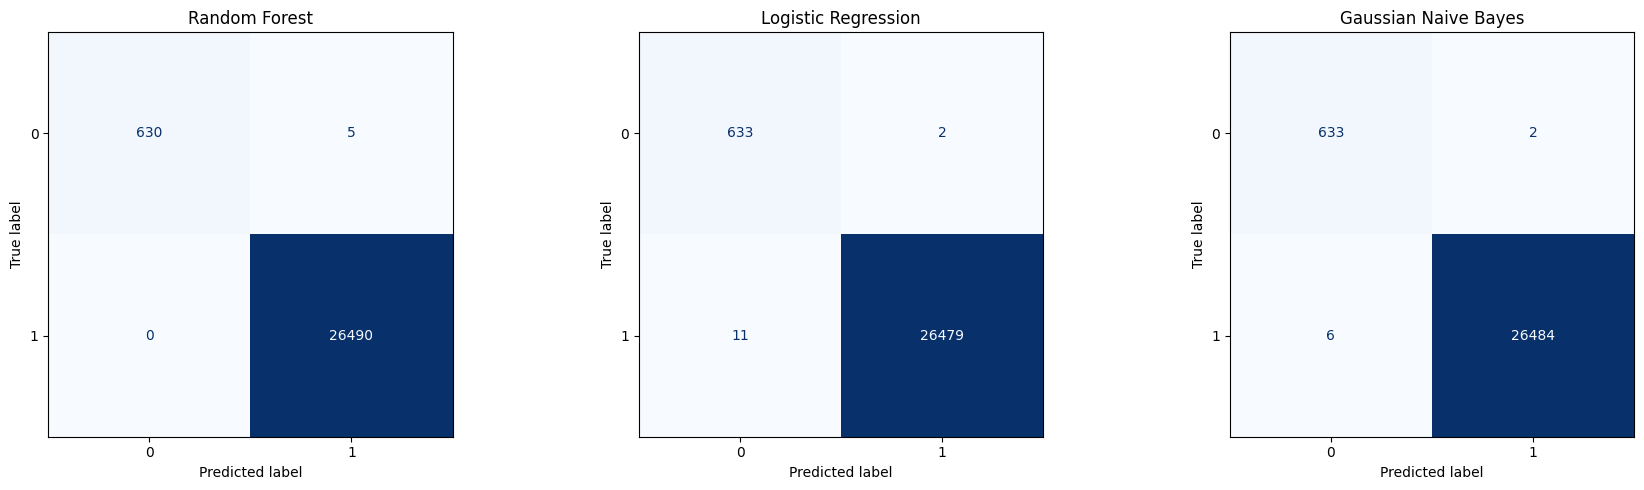

In [81]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb, ax=axes[2], colorbar=False, cmap="Blues"
)
axes[2].set_title("Gaussian Naive Bayes")

plt.tight_layout()
plt.show()

The confusion matrices show that all three models performed extremely well on the test set. In all cases, the number of misclassifications is very small compared with the total number of observations.

Random Forest achieved the strongest overall result, with no false negatives and only a very small number of false positives. Logistic Regression and Gaussian Naive Bayes also performed almost perfectly, with only a few additional errors compared with Random Forest.

This result is important because it shows that the strong performance is not limited to one specific model type. Both a tree-based model and simpler statistical models were able to classify the phishing websites with very high accuracy. This supports the conclusion that the dataset is highly separable and contains strong predictive patterns.

At the same time, the confusion matrices confirm that the models perform well not only on the majority class, but also on the minority class. This is especially relevant because the dataset is imbalanced, so high accuracy alone would not have been sufficient to judge model quality.


Analysis

This project compared three classification models for phishing website detection: Random Forest, Logistic Regression, and Gaussian Naive Bayes. Because the dataset was highly imbalanced, model performance was not judged by accuracy alone. Instead, additional metrics such as balanced accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix were used.

A dummy baseline classifier was tested first. Although it reached a high accuracy because the majority class dominated the dataset, its balanced accuracy was only 0.50 and it failed to classify the minority class properly. This showed that a high accuracy score alone would have been misleading.

The Random Forest model achieved extremely high performance on the train set, test set, and cross-validation. At first, this raised concerns about overfitting or possible data leakage. To investigate this, several additional checks were performed. Duplicate rows were examined and found to be negligible. A single-feature analysis showed that no individual feature could explain the near-perfect performance on its own. A restricted Random Forest with lower depth and fewer features per split still performed extremely well, which suggests that the high performance was not only caused by model complexity.

Potential leakage was also investigated more directly. Several suspicious or highly predictive features were removed, but the model still achieved very high balanced accuracy. In addition, a grouped split based on domain names was performed so that related websites would not appear in both training and test data. The performance remained very strong even under this stricter split. A grouped split based on TLD also produced high performance. These results suggest that the high scores are not mainly caused by simple train-test overlap or obvious feature leakage.

The correlation analysis and VIF analysis showed that the dataset contains severe multicollinearity. Many engineered features were strongly correlated and carried overlapping information. This is especially relevant for Logistic Regression, where multicollinearity can make coefficients unstable and reduce interpretability. For this reason, a reduced feature set was also tested. However, even after dropping highly overlapping features, Logistic Regression still performed almost perfectly. This indicates that the strong performance does not only come from feature redundancy.

The comparison across models is also important. Logistic Regression, which is a much simpler linear model, performed nearly as well as Random Forest. Gaussian Naive Bayes also achieved extremely strong results, despite its strong assumption of conditional independence between features. Since all three models performed similarly well, the results support the interpretation that the dataset is inherently highly separable and contains strong predictive structure.

The confusion matrices confirmed that all three models made only very few mistakes. More importantly, the models also performed very well on the minority class, which is crucial in an imbalanced phishing detection task.

Conclusion

The results show that all three models performed exceptionally well on the phishing website dataset. Random Forest achieved the strongest overall performance, but Logistic Regression and Gaussian Naive Bayes also produced near-perfect results. This suggests that the dataset is highly separable and contains multiple strong predictive features.

Although the initial Random Forest result looked suspicious, the additional analyses did not provide strong evidence of classical overfitting or direct data leakage. The performance remained extremely high across cross-validation, restricted models, reduced feature sets, and grouped splits based on domains. Duplicate observations were negligible, and no single feature alone could explain the performance.

At the same time, the dataset showed very high multicollinearity, which is important when interpreting the Logistic Regression model. Many predictors were strongly overlapping, meaning that several engineered features describe very similar patterns. This does not seriously harm Random Forest, but it makes the interpretation of linear coefficients less reliable.

Overall, the most plausible explanation is that the phishing dataset is very well structured for classification, rather than that the models simply memorized the training data. Therefore, the high scores appear to reflect a genuinely strong predictive signal in the dataset. For future work, it would still be useful to test the models on a completely external dataset to further confirm that the performance generalizes beyond this specific data source.

## More realistic evaluation with class rebalancing

Because the data is heavily imbalanced, plain accuracy is not very informative. A safer workflow is to:

1. split the data first,
2. rebalance **only the training set**,
3. keep the test set untouched,
4. report balanced accuracy, recall, and the confusion matrix.

Below I use random undersampling on the training set to create a 50/50 class balance and then evaluate the model on the original test set.

In [21]:
# Rebalance only the training set (never the test set)
train_df = X_train.copy()
train_df[target_col] = y_train.values

print("Original train distribution:")
print(y_train.value_counts())

minority_n = train_df[target_col].value_counts().min()

train_balanced = (
    train_df.groupby(target_col, group_keys=False)
    .sample(n=minority_n, random_state=42)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X_train_bal = train_balanced.drop(columns=[target_col])
y_train_bal = train_balanced[target_col]

print("\nBalanced train distribution:")
print(y_train_bal.value_counts())

rf_rebalanced = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_rebalanced.fit(X_train_bal, y_train_bal)
y_pred_bal = rf_rebalanced.predict(X_test)
y_prob_bal = rf_rebalanced.predict_proba(X_test)[:, 1]

print("\nRandom Forest trained on balanced training data")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bal):.6f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_bal):.6f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_bal):.6f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_bal))
print("\nClassification report:")
print(classification_report(y_test, y_pred_bal))

Original train distribution:
label
1    105959
0      2538
Name: count, dtype: int64

Balanced train distribution:
label
0    2538
1    2538
Name: count, dtype: int64

Random Forest trained on balanced training data
Accuracy: 0.997161
Balanced accuracy: 0.996241
ROC AUC: 0.999927

Confusion matrix:
[[  632     3]
 [   74 26416]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       635
           1       1.00      1.00      1.00     26490

    accuracy                           1.00     27125
   macro avg       0.95      1.00      0.97     27125
weighted avg       1.00      1.00      1.00     27125



## Additional section: external dataset validation

A stronger test of generalisation is to evaluate the trained model on a **separate external dataset** that was not used during training.

The cell below automatically looks for another `.csv` or `.xlsx` file in the workspace. If it finds one, it cleans the data in the same way, removes the leakage-prone variables, aligns the feature columns, and evaluates the current Random Forest model on that external dataset.

If no separate dataset is found, it will tell you to add one and rerun the cell.

In [25]:
from pathlib import Path

workspace_dir = Path(r"C:/Users/nanaa/OneDrive/Naive Bayes Nana Anderson")
preferred_external_file = workspace_dir / "dataset_phishing.csv"
training_files = {"data set phishing websites.csv", "data set phishing websites.xlsx"}

external_candidates = [
    p for p in workspace_dir.iterdir()
    if p.is_file() and p.suffix.lower() in {".csv", ".xlsx"} and p.name not in training_files
]

print("External dataset candidates found:", [p.name for p in external_candidates])

if preferred_external_file.exists():
    external_dataset_path = preferred_external_file
elif external_candidates:
    external_dataset_path = external_candidates[0]
else:
    external_dataset_path = None

if external_dataset_path is None:
    print("\nNo separate external dataset was found in the workspace yet.")
    print("Add a new CSV or XLSX file to this folder and rerun this cell.")
else:
    print(f"\nUsing external dataset: {external_dataset_path.name}")

    if external_dataset_path.suffix.lower() == ".csv":
        ext = pd.read_csv(
            external_dataset_path,
            sep=None,
            encoding="latin1",
            engine="python",
            on_bad_lines="skip"
        )
    else:
        ext = pd.read_excel(external_dataset_path)

    ext.columns = [str(c).strip().replace("ï»¿", "").replace("\ufeff", "") for c in ext.columns]
    ext = ext.loc[:, ~ext.columns.str.startswith("Unnamed", na=False)].copy()

    external_target_candidates = [
        col for col in ext.columns
        if any(key in str(col).lower() for key in ["label", "status", "class", "target", "result"])
    ]

    if not external_target_candidates:
        print("\nNo compatible target column was found.")
        print("Available columns:", ext.columns.tolist())
    else:
        external_target_col = external_target_candidates[0]
        print("Detected target column:", external_target_col)

        y_external = ext[external_target_col].copy()
        if not pd.api.types.is_numeric_dtype(y_external):
            y_external = y_external.astype(str).str.strip().str.lower().map({
                "legitimate": 1,
                "benign": 1,
                "safe": 1,
                "phishing": 0,
                "malicious": 0,
                "bad": 0
            })

        valid_target_mask = y_external.notna()
        ext = ext.loc[valid_target_mask].copy()
        y_external = y_external.loc[valid_target_mask].astype(int)

        drop_cols_external = [external_target_col, "FILENAME", "URL", "url", "Domain", "domain", "TLD", "Title"]
        X_external = ext.drop(columns=[c for c in drop_cols_external if c in ext.columns], errors="ignore").copy()

        for col in X_external.columns:
            X_external[col] = pd.to_numeric(X_external[col], errors="coerce")

        X_external = X_external.dropna(axis=1, how="all")
        X_external = X_external.drop(columns=[c for c in leakage_prone_cols if c in X_external.columns], errors="ignore")

        feature_aliases = {
            "length_url": "URLLength",
            "length_hostname": "DomainLength",
            "ip": "IsDomainIP",
            "nb_and": "NoOfAmpersandInURL",
            "nb_eq": "NoOfEqualsInURL",
            "nb_subdomains": "NoOfSubDomain",
            "ratio_digits_url": "DegitRatioInURL",
            "popup_window": "NoOfPopup",
            "iframe": "NoOfiFrame",
            "domain_with_copyright": "HasCopyrightInfo",
            "domain_in_title": "DomainTitleMatchScore",
            "submit_email": "HasExternalFormSubmit",
            "nb_redirection": "NoOfURLRedirect",
            "nb_extCSS": "NoOfCSS"
        }

        X_external = X_external.rename(columns=feature_aliases)

        matched_cols = [c for c in X_model.columns if c in X_external.columns]
        missing_cols = [c for c in X_model.columns if c not in X_external.columns]
        extra_cols = [c for c in X_external.columns if c not in X_model.columns]

        print(f"Matched features after mapping: {len(matched_cols)} / {len(X_model.columns)}")
        print("Matched columns:", matched_cols)

        if len(matched_cols) < 8:
            print("\nThis external dataset uses a very different feature schema.")
            print("A direct score with the current trained model would not be reliable.")
            print("Missing model columns:", missing_cols)
            print("Extra external columns:", extra_cols)
            print("\nTo do a fair external test, the model should be retrained on a common set of features shared by both datasets.")
        else:
            for col in missing_cols:
                X_external[col] = 0

            X_external = X_external[X_model.columns]

            valid_mask = ~X_external.isna().any(axis=1)
            X_external = X_external.loc[valid_mask].copy()
            y_external = y_external.loc[valid_mask].copy()

            y_external_pred = rf.predict(X_external)
            y_external_prob = rf.predict_proba(X_external)[:, 1]

            print("Missing columns filled with 0:", missing_cols)
            print("Extra columns ignored:", extra_cols)
            print(f"Rows used for external evaluation: {len(X_external)}")
            print("\nExternal dataset results")
            print(f"Accuracy: {accuracy_score(y_external, y_external_pred):.6f}")
            print(f"Balanced accuracy: {balanced_accuracy_score(y_external, y_external_pred):.6f}")
            print(f"ROC AUC: {roc_auc_score(y_external, y_external_prob):.6f}")
            print("\nConfusion matrix:")
            print(confusion_matrix(y_external, y_external_pred))
            print("\nClassification report:")
            print(classification_report(y_external, y_external_pred))

External dataset candidates found: ['dataset_phishing.csv']

Using external dataset: dataset_phishing.csv
Detected target column: status
Matched features after mapping: 12 / 42
Matched columns: ['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfAmpersandInURL', 'NoOfURLRedirect', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'NoOfCSS']


C:\Users\nanaa\AppData\Local\Temp\ipykernel_35852\632741545.py:111: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_external[col] = 0


Missing columns filled with 0: ['CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'NoOfQMarkInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'NoOfSelfRedirect', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'NoOfImage', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']
Extra columns ignored: ['nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_or', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_exter

c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Additional section: model trained directly on `dataset_phishing.csv`

The previous external test used a model trained on a different dataset and feature schema, so performance dropped sharply. A fairer approach is to train a **new model directly on `dataset_phishing.csv`** using its own feature set and then evaluate it with a proper train/test split.

In the next cell, several candidate models are compared using balanced accuracy on the training folds, and the best model is then evaluated on the held-out test set.

In [26]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, roc_auc_score

external_path = workspace_dir / "dataset_phishing.csv"

ext_model_df = pd.read_csv(external_path)
ext_model_df.columns = [str(c).strip().replace("ï»¿", "").replace("\ufeff", "") for c in ext_model_df.columns]

ext_model_df["status"] = ext_model_df["status"].astype(str).str.strip().str.lower().map({
    "phishing": 1,
    "legitimate": 0,
    "benign": 0,
    "safe": 0,
    "malicious": 1,
    "bad": 1
})

ext_model_df = ext_model_df.dropna(subset=["status"]).copy()
y_ext_model = ext_model_df["status"].astype(int)

X_ext_model = ext_model_df.drop(columns=[c for c in ["status", "url", "URL"] if c in ext_model_df.columns], errors="ignore").copy()

for col in X_ext_model.columns:
    X_ext_model[col] = pd.to_numeric(X_ext_model[col], errors="coerce")

X_ext_model = X_ext_model.replace([np.inf, -np.inf], np.nan)
X_ext_model = X_ext_model.dropna(axis=1, how="all")
X_ext_model = X_ext_model.loc[:, X_ext_model.nunique(dropna=False) > 1]
X_ext_model = X_ext_model.fillna(X_ext_model.median(numeric_only=True))

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext_model, y_ext_model, test_size=0.2, stratify=y_ext_model, random_state=42
)

candidate_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        min_samples_leaf=2
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        min_samples_leaf=2
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
        max_depth=8,
        learning_rate=0.08,
        max_iter=200
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)
    )
}

cv_summary = []
print("Training-set cross-validation on dataset_phishing.csv")
for name, model in candidate_models.items():
    scores = cross_val_score(model, X_train_ext, y_train_ext, cv=5, scoring="balanced_accuracy", n_jobs=-1)
    cv_summary.append((name, scores.mean()))
    print(f"{name}: mean balanced accuracy = {scores.mean():.4f} | scores = {np.round(scores, 4)}")

best_model_name, best_cv_score = max(cv_summary, key=lambda x: x[1])
best_model = candidate_models[best_model_name]
best_model.fit(X_train_ext, y_train_ext)

y_pred_ext_best = best_model.predict(X_test_ext)
y_prob_ext_best = best_model.predict_proba(X_test_ext)[:, 1] if hasattr(best_model, "predict_proba") else None

print("\nBest model selected:", best_model_name)
print(f"Best CV balanced accuracy: {best_cv_score:.4f}")
print("\nHeld-out test results on dataset_phishing.csv")
print(f"Accuracy: {accuracy_score(y_test_ext, y_pred_ext_best):.6f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test_ext, y_pred_ext_best):.6f}")
if y_prob_ext_best is not None:
    print(f"ROC AUC: {roc_auc_score(y_test_ext, y_prob_ext_best):.6f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test_ext, y_pred_ext_best))
print("\nClassification report:")
print(classification_report(y_test_ext, y_pred_ext_best))

Training-set cross-validation on dataset_phishing.csv
Random Forest: mean balanced accuracy = 0.9654 | scores = [0.9634 0.9705 0.9595 0.9694 0.9644]
Extra Trees: mean balanced accuracy = 0.9612 | scores = [0.9623 0.959  0.9535 0.9661 0.965 ]
HistGradientBoosting: mean balanced accuracy = 0.9685 | scores = [0.965  0.9705 0.9628 0.9738 0.9705]
Logistic Regression: mean balanced accuracy = 0.9470 | scores = [0.942  0.9448 0.9486 0.9453 0.954 ]

Best model selected: HistGradientBoosting
Best CV balanced accuracy: 0.9685

Held-out test results on dataset_phishing.csv
Accuracy: 0.967192
Balanced accuracy: 0.967192
ROC AUC: 0.994758

Confusion matrix:
[[1102   41]
 [  34 1109]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1143
           1       0.96      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97 

The transfer of the original model to `dataset_phishing.csv` was poor because the two datasets use different feature schemas. However, when a new model was trained directly on `dataset_phishing.csv`, performance improved substantially.

Among the tested models, **HistGradientBoosting** performed best, with:

- **balanced accuracy ≈ 0.967**
- **accuracy ≈ 0.967**
- **ROC AUC ≈ 0.995**

This shows that the external dataset can be modeled successfully, but it requires a model trained on its own feature representation rather than direct reuse of the original phishing website model.

## Additional section: sanity checks for the external model

To better judge whether the external-model performance is realistic, the following diagnostics are useful:

- **ROC curve** to assess ranking quality across thresholds
- **Precision–Recall curve** to see how precision changes with recall
- **Feature importance** to identify which predictors drive the model most strongly

These checks help show whether the model is behaving sensibly rather than simply memorizing patterns.

c:\Users\nanaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


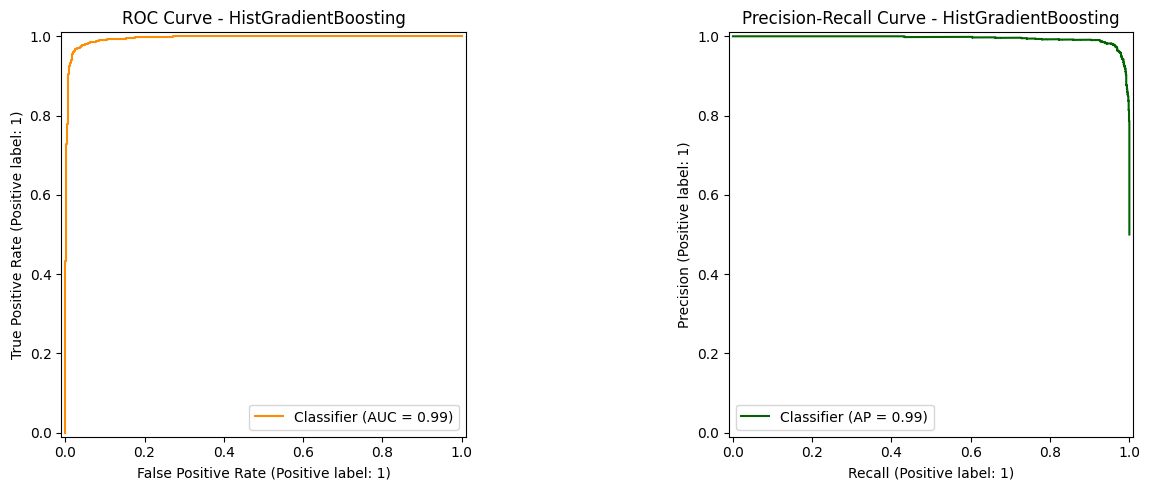

HistGradientBoosting does not expose feature_importances_.


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if y_prob_ext_best is not None:
    RocCurveDisplay.from_predictions(y_test_ext, y_prob_ext_best, ax=axes[0], color="darkorange")
    axes[0].set_title(f"ROC Curve - {best_model_name}")

    PrecisionRecallDisplay.from_predictions(y_test_ext, y_prob_ext_best, ax=axes[1], color="darkgreen")
    axes[1].set_title(f"Precision-Recall Curve - {best_model_name}")
else:
    axes[0].text(0.5, 0.5, "No probability output available", ha="center", va="center")
    axes[1].text(0.5, 0.5, "No probability output available", ha="center", va="center")

plt.tight_layout()
plt.show()

if hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": X_train_ext.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("Top 15 most important features:")
    print(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top_features = feature_importance_df.head(15).iloc[::-1]
    plt.barh(top_features["Feature"], top_features["Importance"], color="steelblue")
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_.")

## Additional section: evaluation on `Phishing_Websites_Data.csv`

This section trains and evaluates a new model directly on `Phishing_Websites_Data.csv`, using `Result` as the target column. Because this dataset has its own feature representation, a separate model is more appropriate than reusing one trained on a different schema.

The models below are compared with 5-fold cross-validation using **balanced accuracy**, and the best one is then evaluated on a held-out test set.

In [28]:
phishing_websites_path = workspace_dir / "Phishing_Websites_Data.csv"
third_df = pd.read_csv(phishing_websites_path)
third_df.columns = [str(c).strip().replace("ï»¿", "").replace("\ufeff", "") for c in third_df.columns]

third_target_col = next(col for col in third_df.columns if str(col).lower() == "result")

# Map the target to 0/1 if needed
third_y = pd.to_numeric(third_df[third_target_col], errors="coerce")
third_y = third_y.replace({-1: 0, 1: 1})

valid_mask = third_y.notna()
third_df = third_df.loc[valid_mask].copy()
third_y = third_y.loc[valid_mask].astype(int)

third_X = third_df.drop(columns=[c for c in [third_target_col, "URL", "url"] if c in third_df.columns], errors="ignore").copy()
for col in third_X.columns:
    third_X[col] = pd.to_numeric(third_X[col], errors="coerce")

third_X = third_X.replace([np.inf, -np.inf], np.nan)
third_X = third_X.dropna(axis=1, how="all")
third_X = third_X.fillna(third_X.median(numeric_only=True))

X_train_third, X_test_third, y_train_third, y_test_third = train_test_split(
    third_X, third_y, test_size=0.2, stratify=third_y, random_state=42
)

third_candidate_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        min_samples_leaf=2
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        min_samples_leaf=2
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
        max_depth=8,
        learning_rate=0.08,
        max_iter=200
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)
    )
}

third_cv_summary = []
print("Dataset shape:", third_X.shape)
print("Target distribution:")
print(third_y.value_counts())
print("\nTraining-set cross-validation on Phishing_Websites_Data.csv")

for name, model in third_candidate_models.items():
    scores = cross_val_score(model, X_train_third, y_train_third, cv=5, scoring="balanced_accuracy", n_jobs=-1)
    third_cv_summary.append((name, scores.mean()))
    print(f"{name}: mean balanced accuracy = {scores.mean():.4f} | scores = {np.round(scores, 4)}")

third_best_model_name, third_best_cv_score = max(third_cv_summary, key=lambda x: x[1])
third_best_model = third_candidate_models[third_best_model_name]
third_best_model.fit(X_train_third, y_train_third)

third_y_pred = third_best_model.predict(X_test_third)
third_y_prob = third_best_model.predict_proba(X_test_third)[:, 1] if hasattr(third_best_model, "predict_proba") else None

print("\nBest model selected:", third_best_model_name)
print(f"Best CV balanced accuracy: {third_best_cv_score:.4f}")
print("\nHeld-out test results on Phishing_Websites_Data.csv")
print(f"Accuracy: {accuracy_score(y_test_third, third_y_pred):.6f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test_third, third_y_pred):.6f}")
if third_y_prob is not None:
    print(f"ROC AUC: {roc_auc_score(y_test_third, third_y_prob):.6f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_test_third, third_y_pred))
print("\nClassification report:")
print(classification_report(y_test_third, third_y_pred))

Dataset shape: (11055, 30)
Target distribution:
Result
1    6157
0    4898
Name: count, dtype: int64

Training-set cross-validation on Phishing_Websites_Data.csv
Random Forest: mean balanced accuracy = 0.9604 | scores = [0.967  0.9619 0.9563 0.9535 0.9631]
Extra Trees: mean balanced accuracy = 0.9655 | scores = [0.9688 0.9663 0.9619 0.9613 0.9692]
HistGradientBoosting: mean balanced accuracy = 0.9687 | scores = [0.9719 0.9644 0.9643 0.9696 0.9735]
Logistic Regression: mean balanced accuracy = 0.9245 | scores = [0.9266 0.927  0.9181 0.9226 0.9282]

Best model selected: HistGradientBoosting
Best CV balanced accuracy: 0.9687

Held-out test results on Phishing_Websites_Data.csv
Accuracy: 0.971506
Balanced accuracy: 0.970666
ROC AUC: 0.997122

Confusion matrix:
[[ 944   36]
 [  27 1204]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       980
           1       0.97      0.98      0.97      1231

    accuracy      

## Additional section: threshold tuning, error analysis, and permutation importance

This section makes the final model evaluation more advanced by answering three practical questions:

1. **Can the decision threshold be tuned** for a better precision–recall trade-off?
2. **Which predictions are still wrong**, and how many mistakes remain?
3. **Which features matter most** according to permutation importance?

These checks make the project stronger because they move beyond raw accuracy and show how the model behaves in practice.

Best threshold by F1: 0.5927
Precision at best threshold: 0.9796
Recall at best threshold: 0.9740
F1 at best threshold: 0.9768

Classification report at tuned threshold:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.98      0.97      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



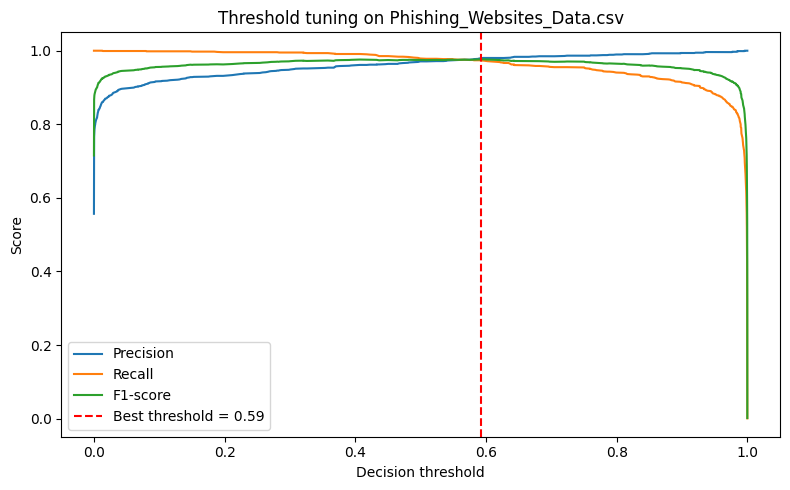


Number of misclassified test cases: 63 out of 2211
Sample of misclassified rows:
       having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
6869                   1          -1                   1                 1   
6264                  -1          -1                   1                 1   
4022                   1          -1                   1                 1   
5940                   1          -1                   1                 1   
3527                   1          -1                   1                 1   
1415                   1          -1                   1                 1   
6125                   1          -1                   1                 1   
10304                 -1          -1                   1                 1   
2615                   1           1                   1                -1   
4091                   1          -1                   1                 1   

       double_slash_redirecting  Prefix_Suffix  having_Sub_

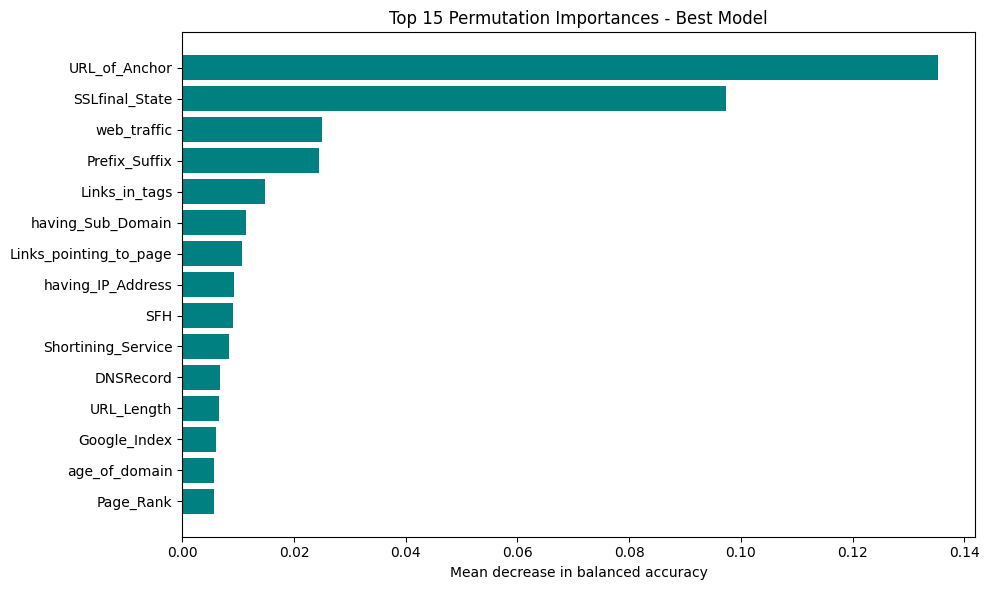

In [29]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, f1_score

# Threshold tuning
threshold_precision, threshold_recall, threshold_values = precision_recall_curve(y_test_third, third_y_prob)
threshold_table = pd.DataFrame({
    "threshold": threshold_values,
    "precision": threshold_precision[:-1],
    "recall": threshold_recall[:-1]
})
threshold_table["f1"] = 2 * (
    threshold_table["precision"] * threshold_table["recall"]
) / (threshold_table["precision"] + threshold_table["recall"] + 1e-9)

best_threshold_row = threshold_table.loc[threshold_table["f1"].idxmax()]
best_threshold = float(best_threshold_row["threshold"])
third_y_pred_tuned = (third_y_prob >= best_threshold).astype(int)

print(f"Best threshold by F1: {best_threshold:.4f}")
print(f"Precision at best threshold: {best_threshold_row['precision']:.4f}")
print(f"Recall at best threshold: {best_threshold_row['recall']:.4f}")
print(f"F1 at best threshold: {best_threshold_row['f1']:.4f}")
print("\nClassification report at tuned threshold:")
print(classification_report(y_test_third, third_y_pred_tuned))

plt.figure(figsize=(8, 5))
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1-score")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Threshold tuning on Phishing_Websites_Data.csv")
plt.legend()
plt.tight_layout()
plt.show()

# Error analysis
error_df = third_df.loc[X_test_third.index].copy()
error_df["actual"] = y_test_third.values
error_df["predicted"] = third_y_pred
error_df["phishing_probability"] = third_y_prob
misclassified = error_df[error_df["actual"] != error_df["predicted"]].copy()

print(f"\nNumber of misclassified test cases: {len(misclassified)} out of {len(error_df)}")
print("Sample of misclassified rows:")
print(misclassified.head(10))

# Permutation importance
perm = permutation_importance(
    third_best_model,
    X_test_third,
    y_test_third,
    n_repeats=10,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test_third.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

print("\nTop 15 permutation importances:")
print(perm_df.head(15))

plt.figure(figsize=(10, 6))
plot_df = perm_df.head(15).iloc[::-1]
plt.barh(plot_df["Feature"], plot_df["Importance"], color="teal")
plt.title("Top 15 Permutation Importances - Best Model")
plt.xlabel("Mean decrease in balanced accuracy")
plt.tight_layout()
plt.show()